#  E-Commerce Statistical Analysis Project
This project performs statistical testing on e-commerce transaction data to uncover insights about pricing, quantity, and revenue.


In [115]:
import pandas as pd
import numpy as np
from scipy import stats
import os
import matplotlib.pyplot as plt
import seaborn as sb


### Data Loading & Initial Setup
We start by loading the dataset and inspecting its structure.

In [116]:
file_path = '/home/mobinabedian/data_science/Assignment_1/data/Statistical_Testing on E_ndash_Commerce_data/data.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')

### Data Cleaning & Feature Engineering
To ensure the quality of our statistical tests, we must:
* Remove records with non-positive `Quantity` or `UnitPrice`.
* Create a new `Revenue` column ($Quantity \times UnitPrice$).

In [117]:
df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()

In [118]:
df_clean['revenue'] = df_clean['UnitPrice']*df_clean['Quantity']

In [119]:
print(df_clean.head(50))

   InvoiceNo StockCode                          Description  Quantity  \
0     536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1     536365     71053                  WHITE METAL LANTERN         6   
2     536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3     536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4     536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
5     536365     22752         SET 7 BABUSHKA NESTING BOXES         2   
6     536365     21730    GLASS STAR FROSTED T-LIGHT HOLDER         6   
7     536366     22633               HAND WARMER UNION JACK         6   
8     536366     22632            HAND WARMER RED POLKA DOT         6   
9     536367     84879        ASSORTED COLOUR BIRD ORNAMENT        32   
10    536367     22745           POPPY'S PLAYHOUSE BEDROOM          6   
11    536367     22748            POPPY'S PLAYHOUSE KITCHEN         6   
12    536367     22749    FELTCRAFT PRINCESS CHARLO

In [120]:
print(df_clean.info())


<class 'pandas.DataFrame'>
Index: 530104 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    530104 non-null  str    
 1   StockCode    530104 non-null  str    
 2   Description  530104 non-null  str    
 3   Quantity     530104 non-null  int64  
 4   InvoiceDate  530104 non-null  str    
 5   UnitPrice    530104 non-null  float64
 6   CustomerID   397884 non-null  float64
 7   Country      530104 non-null  str    
 8   revenue      530104 non-null  float64
dtypes: float64(3), int64(1), str(5)
memory usage: 40.4 MB
None


In [121]:
df_clean.describe()

,Quantity,UnitPrice,CustomerID,revenue
count,530104.000000,530104.000000,397884.000000,530104.000000
mean,10.542037,3.907625,15294.423453,20.121871
std,155.524124,35.915681,1713.141560,270.356743
min,1.000000,0.001000,12346.000000,0.001000
25%,1.000000,1.250000,13969.000000,3.750000
50%,3.000000,2.080000,15159.000000,9.900000
75%,10.000000,4.130000,16795.000000,17.700000
max,80995.000000,13541.330000,18287.000000,168469.600000


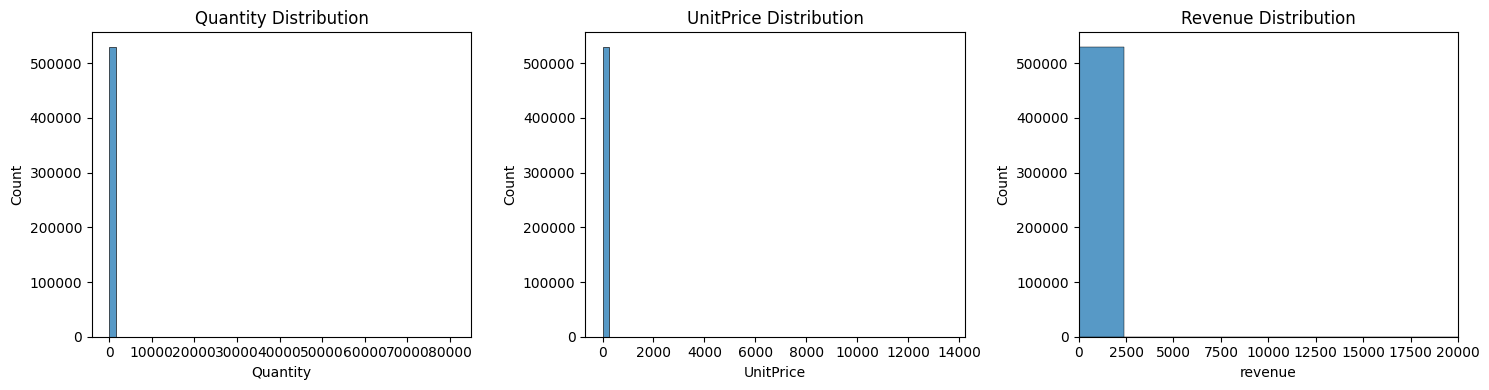

In [122]:
os.makedirs("figures", exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sb.histplot(df_clean['Quantity'], bins=50, ax=axes[0])
axes[0].set_title("Quantity Distribution")
sb.histplot(df_clean['UnitPrice'], bins=50, ax=axes[1])
axes[1].set_title("UnitPrice Distribution")
sb.histplot(df_clean['revenue'], bins=70, ax=axes[2])
axes[2].set_title("Revenue Distribution")
axes[2].set_xlim(0,20000)
plt.tight_layout()
plt.savefig("figures/initial_histograms.png", dpi=300, bbox_inches="tight")
plt.show()



In [123]:
df_clean.nlargest(10, 'Quantity')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,12/9/2011 9:15,2.08,16446.0,United Kingdom,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1/18/2011 10:01,1.04,12346.0,United Kingdom,77183.60
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,10/27/2011 12:26,0.21,12901.0,United Kingdom,1008.00
206121,554868,22197,SMALL POPCORN HOLDER,4300,5/27/2011 10:52,0.72,13135.0,United Kingdom,3096.00
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,2/22/2011 10:43,0.82,18087.0,United Kingdom,3202.92
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,7/19/2011 17:04,0.06,14609.0,United Kingdom,191.16
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,1/11/2011 12:55,2.10,15749.0,United Kingdom,6539.40
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,4/18/2011 13:20,2.10,15749.0,United Kingdom,6539.40
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,11/2/2011 11:24,0.32,16308.0,United Kingdom,960.00
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,12/2/2010 17:38,0.18,16754.0,United Kingdom,518.40


In [124]:
for col in ['Quantity', 'UnitPrice', 'revenue']:
    print("\n", col)
    print(df_clean[col].quantile([0.9, 0.95, 0.99, 0.999]))


 Quantity
0.900     24.000
0.950     30.000
0.990    100.000
0.999    449.794
Name: Quantity, dtype: float64

 UnitPrice
0.900      7.95
0.950      9.95
0.990     16.98
0.999    165.00
Name: UnitPrice, dtype: float64

 revenue
0.900     32.85
0.950     59.70
0.990    183.60
0.999    835.20
Name: revenue, dtype: float64


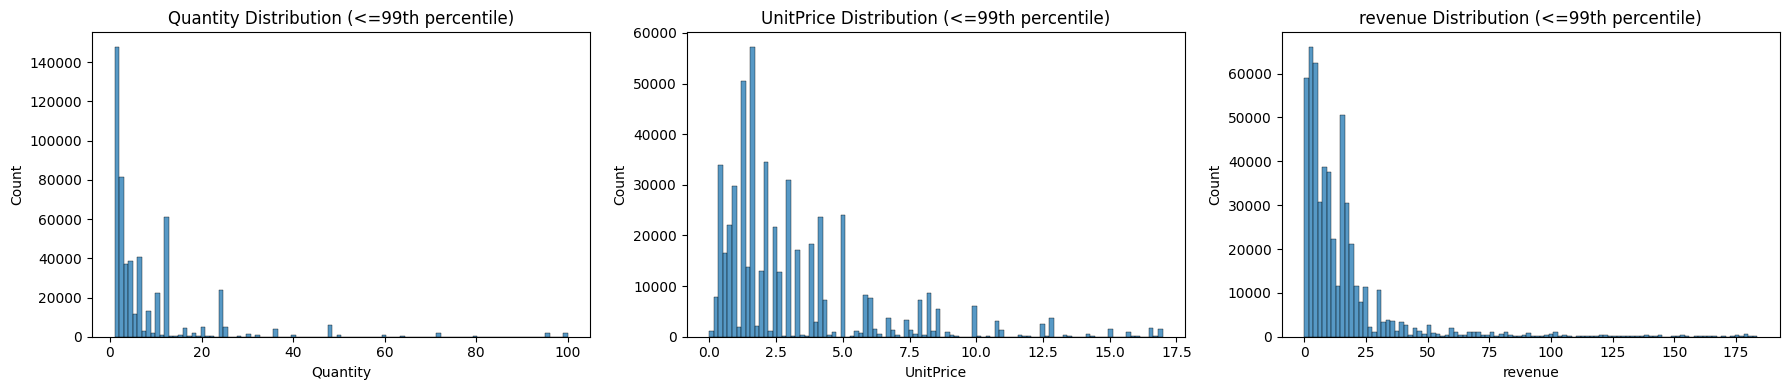

In [125]:
os.makedirs("figures", exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

cols = ['Quantity', 'UnitPrice', 'revenue']

for i, col in enumerate(cols):

    q99 = df_clean[col].quantile(0.99)

    filtered = df_clean[df_clean[col] <= q99]

    sb.histplot(filtered[col], bins=100, ax=axes[i])

    axes[i].set_title(f"{col} Distribution (<=99th percentile)")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()

plt.savefig(
    "figures/clipped_histograms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The original histograms were heavily affected by extreme outliers, causing most values to appear compressed near zero. To improve readability, 99th percentile clipping was applied for visualization purposes only.

## Test 1: Normality of Revenue
**Question:** Does the distribution of line item revenue resemble a normal distribution?

**Hypotheses:**
*   $H_0$: The sampled revenue values come from a normal distribution.
*   $H_1$: The sampled revenue values do not come from a normal distribution.
*   **Significance Level ($\alpha$):** 0.05

In [126]:
samlple_data =  df_clean["revenue"].sample(500)

In [127]:
stat, p_value = stats.shapiro(samlple_data)

In [128]:
print(f"Statistic: {stat:.4f}, P-value: {p_value:.4f}")

Statistic: 0.2061, P-value: 0.0000


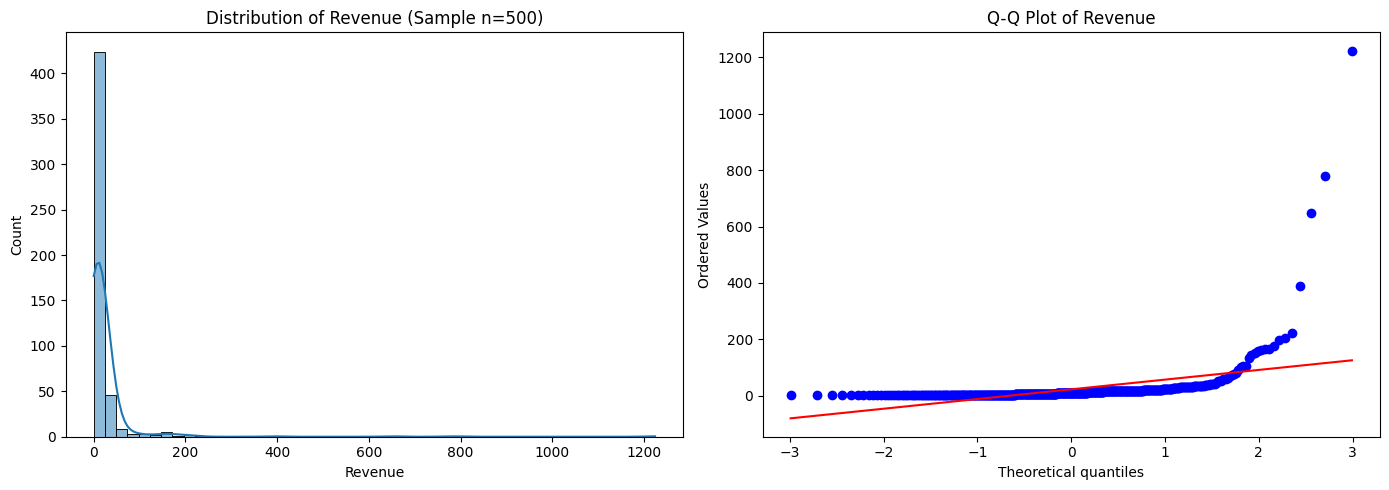

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sb.histplot(samlple_data, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Revenue (Sample n=500)")
axes[0].set_xlabel("Revenue")
stats.probplot(samlple_data, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Revenue")
plt.tight_layout()
plt.savefig("figures/revenue_normality.png", dpi=300, bbox_inches="tight")
plt.show()


> **Conclusion:**
> Since the **p-value (0.0000)** is less than our significance level **($\alpha = 0.05$)**, we **reject $H_0$**. 
> This means we have enough statistical evidence to say that the `UnitPrice` is **not normally distributed**.

## Test 2: Association between Quantity and Unit Price
**Question:** Is there an association between quantity ordered and unit price?

**Description:**
Since our data is **not normal** and the relationship might not be strictly linear, we use the **Spearman Rank Correlation** to check for a monotonic association.

**Hypotheses:**
*   $H_0$: There is no monotonic association between quantity and unit price.
*   $H_1$: There is a monotonic association between quantity and unit price.
*   **Significance Level ($\alpha$):** 0.05

In [130]:
corr, p_val_corr = stats.spearmanr(df_clean['Quantity'],df_clean['UnitPrice'])
print(f"Spearman Correlation: {corr:.4f}")
print(f"P_value: {p_val_corr:.4f}")

Spearman Correlation: -0.4032
P_value: 0.0000


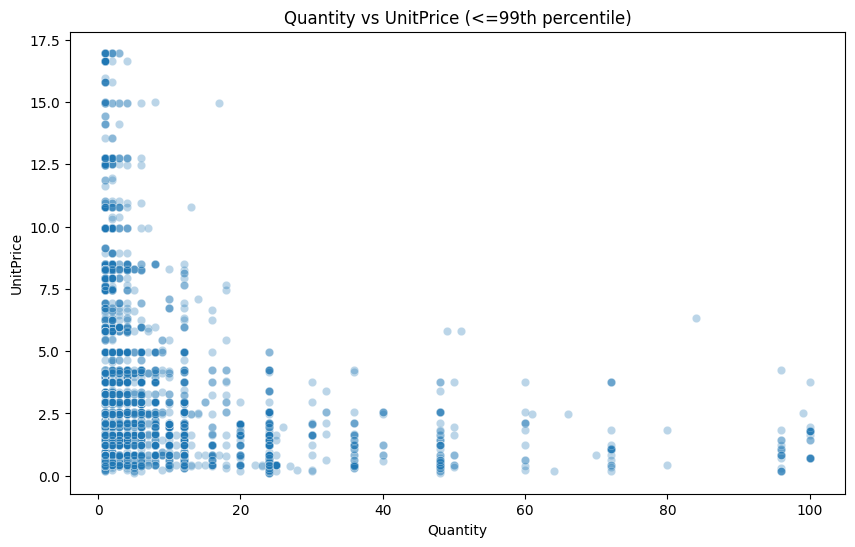

In [131]:
q_quantity = df_clean['Quantity'].quantile(0.99)
q_price = df_clean['UnitPrice'].quantile(0.99)

filtered = df_clean[
    (df_clean['Quantity'] <= q_quantity) &
    (df_clean['UnitPrice'] <= q_price)
]

sample_scatter = filtered.sample(5000, random_state=42)

plt.figure(figsize=(10,6))

sb.scatterplot(
    data=sample_scatter,
    x='Quantity',
    y='UnitPrice',
    alpha=0.3
)

plt.title("Quantity vs UnitPrice (<=99th percentile)")
plt.savefig("figures/quantity_price_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

> **Conclusion:**
> **P-value (0.0000) < 0.05**
>
> Result: **Reject $H_0$** 
>
> **Analysis:** There is a **statistically significant**, **moderate negative** correlation ($-0.4032$) between `Quantity` and `UnitPrice`. 
> As price increases, quantity tends to decrease.

## Test 3: Revenue Comparison (UK vs. International)
**Question:** Do line item revenues differ on average between the United Kingdom and all other countries combined?

In this step, we split our cleaned data into two distinct groups based on the `Country` column:
1. **UK Group:** Transactions originating from the United Kingdom.
2. **Other Group:** A combined group of all international transactions.

In [139]:
uk = df_clean[df_clean['Country'] == 'United Kingdom'].copy()
other = df_clean[df_clean['Country'] != 'United Kingdom'].copy()

uk['revenue'] = uk['Quantity'] * uk['UnitPrice']
other['revenue'] = other['Quantity'] * other['UnitPrice']

print(f"UK Samples: {len(uk)}")
print(f"Other Samples: {len(other)}")

UK Samples: 485123
Other Samples: 44981


####  Assumption Check: Homogeneity of Variances
Before running the T-test, we must verify the assumption of equal variances using **Levene's Test**.
* **$H_0$:** The variance of revenue is equal across both groups.
* **$H_1$:** The variances are significantly different.

*Note: If the p-value is less than 0.05, we must use **Welch's T-test** (by setting `equal_var=False`) to ensure the results are valid despite the unequal variances.*

In [143]:
stat_levene, p_levene = stats.levene(uk['revenue'], other['revenue'])

print(f"Levene Test P-value: {p_levene:.4f}")
print(f"UK Variance: {uk['revenue'].var():.2f}")
print(f"Other Variance: {other['revenue'].var():.2f}")

Levene Test P-value: 0.0000
UK Variance: 79118.57
Other Variance: 7811.61


####  Independent Samples T-test (Welch's Version)
Now we perform the final statistical comparison of the mean revenue between the two groups.
* **$H_0$:** $\mu_{UK} = \mu_{Other}$ (There is no significant difference in average revenue).
* **$H_1$:** $\mu_{UK} \neq \mu_{Other}$ (There is a significant difference in average revenue).

Based on our previous variance check, we are using **Welch's T-test** to account for potential differences in sample sizes and variances.

In [146]:
t_stat, p_val = stats.ttest_ind(uk['revenue'], other['revenue'], equal_var=False)

print(f"UK Mean: {uk['revenue'].mean():.2f}")
print(f"Other countries Mean: {other['revenue'].mean():.2f}")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

UK Mean: 18.60
Other countries Mean: 36.49
T-Statistic: -30.8258
P-value: 0.0000


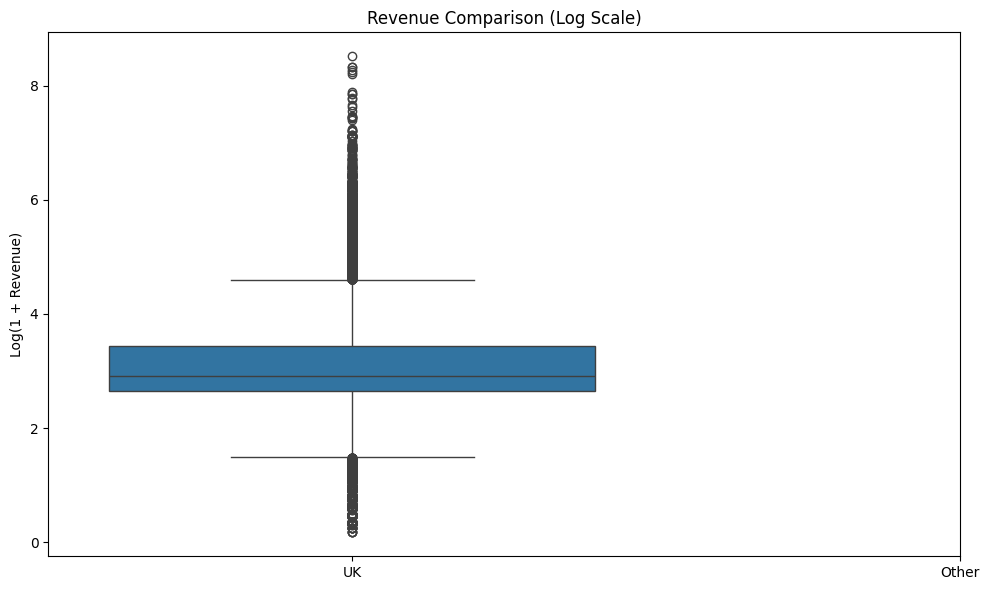

In [151]:
uk_log = np.log1p(uk['revenue'])
other_log = np.log1p(other['revenue'])

plt.figure(figsize=(10,6))

sb.boxplot(data=[uk_log, other_log])

plt.xticks([0,1], ['UK', 'Other'])
plt.ylabel("Log(1 + Revenue)")
plt.title("Revenue Comparison (Log Scale)")

plt.tight_layout()
plt.savefig("figures/uk_vs_other_boxplot_log.png", dpi=300)
plt.show()

###  Conclusion for Test 3
**Statistical Results:**
*   **UK Mean Revenue:** 18.60
*   **Other Countries Mean Revenue:** 36.49
*   **T-Statistic:** -30.8258
*   **P-value:** 0.0000

**Interpretation:**
Since the **P-value (0.0000)** is much smaller than the significance level ($\alpha = 0.05$), we **reject the null hypothesis ($H_0$)**

This result indicates a **statistically significant difference** between the average revenue of the United Kingdom and all other countries combined. On average, international transactions (Other countries) generate significantly higher revenue per line item compared to domestic transactions in the UK.

## Test 4: Revenue across top countries
**Question:** Among the top countries by number of transactions, are the mean revenues the same?

**Hypotheses:**
*   $H_0$: The mean revenue is the same across the top 5 countries ($\mu_1 = \mu_2 = \mu_3 = \mu_4 = \mu_5$).
*   $H_1$: At least one country has a different mean revenue.

**Approach:**
1. Identify the top 5 countries by transaction count.
2. Use One-Way ANOVA to compare their mean revenues.

In [23]:
top_5_countries = df_clean['Country'].value_counts().head().index.tolist()
print("Top 5 Countries:",top_5_countries)
df_top5 = df_clean[df_clean['Country'].isin(top_5_countries)]

group1 = df_clean[df_clean['Country'] == 'United Kingdom']['revenue']
group2 = df_clean[df_clean['Country'] == 'Germany']['revenue']
group3 = df_clean[df_clean['Country'] == 'France']['revenue']
group4 = df_clean[df_clean['Country'] == 'EIRE']['revenue']
group5 = df_clean[df_clean['Country'] == 'Spain']['revenue']

Top 5 Countries: ['United Kingdom', 'Germany', 'France', 'EIRE', 'Spain']


In [25]:
f_stat, p_val_anova = stats.f_oneway(group1, group2, group3, group4, group5)

In [26]:
print(f"UK Mean: {group1.mean():.2f}")
print(f"Germany Mean: {group2.mean():.2f}")
print(f"France Mean: {group3.mean():.2f}")
print(f"EIRE Mean: {group4.mean():.2f}")
print(f"Spain Mean: {group5.mean():.2f}")

print("-" * 30)
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-value: {p_val_anova:.4f}")

UK Mean: 18.60
Germany Mean: 25.32
France Mean: 24.95
EIRE Mean: 35.93
Spain Mean: 24.79
------------------------------
F-Statistic: 10.2228
P-value: 0.0000


### Conclusion for Test 4 (ANOVA)
**Statistical Results:**
*   **F-Statistic:** 10.2228
*   **P-value:** 0.0000

**Interpretation:**
Since the **P-value (0.0000)** is less than the significance level ($\alpha = 0.05$), we **reject the null hypothesis ($H_0$)**. 

This means there is a **statistically significant difference** in the mean revenue among at least one of the top 5 countries. Looking at the group means, **EIRE** shows a notably higher average revenue (35.93) compared to the **UK** (18.60), while Germany, France, and Spain have relatively similar averages around 24-25.

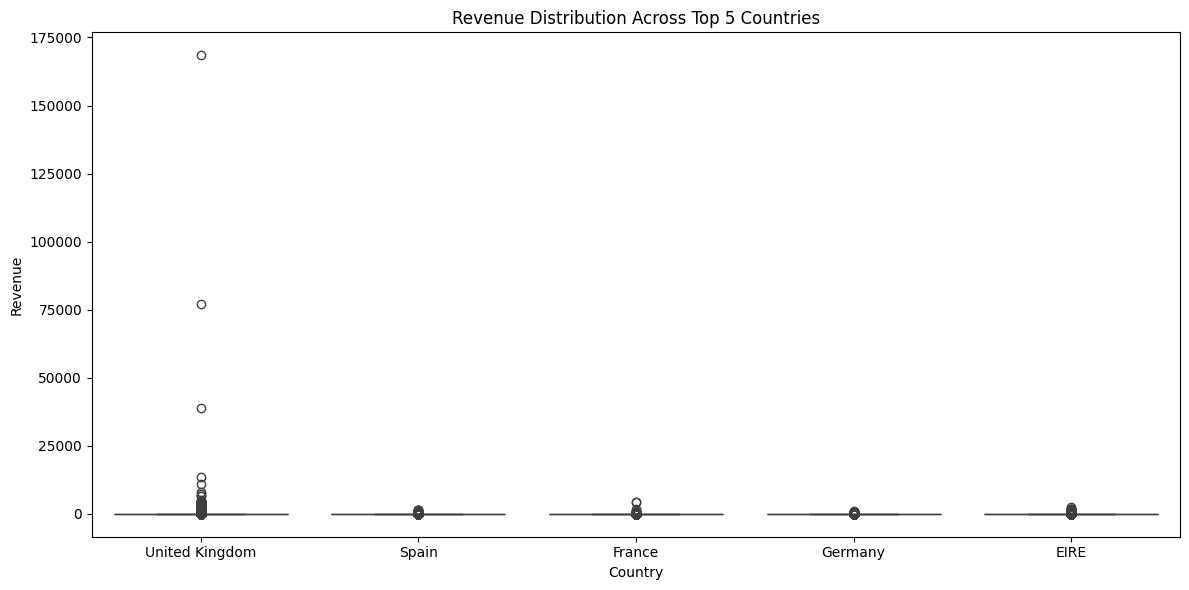

In [27]:
plt.figure(figsize=(12, 6))
order = df_top5.groupby('Country')['revenue'].median().sort_values().index
sb.boxplot(data=df_top5, x='Country', y='revenue', order=order)
plt.title("Revenue Distribution Across Top 5 Countries")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("figures/top5_revenue_anova.png", dpi=300, bbox_inches="tight")
plt.show()


## Test 5: Association between Country and High Value Purchase
**Question:** Is the proportion of high-value purchases the same across the main countries?

**Hypotheses:**
*   $H_0$: High-value purchases are independent of the country (proportions are the same).
*   $H_1$: There is a significant association between country and high-value purchases.

**Method:**
1. Define "High Value" (e.g., revenue > 20).
2. Create a contingency table (Cross-tabulation).
3. Perform the **Chi-Square Test of Independence**

In [28]:
threshold = 20
df_clean["is_high_value"] = df_clean['revenue'] > threshold
df_chi = df_clean[df_clean['Country'].isin(top_5_countries)]
contingency_table = pd.crosstab(df_chi['Country'], df_chi['is_high_value'])
chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency_table)
print("Contingency Table:")
print(contingency_table)
print("-" * 30)
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p_val_chi:.4f}")

Contingency Table:
is_high_value    False  True 
Country                      
EIRE              5146   2744
France            5780   2627
Germany           6280   2760
Spain             1924    560
United Kingdom  401265  83858
------------------------------
Chi-Square Statistic: 3661.1035
Degrees of Freedom: 4
P-value: 0.0000


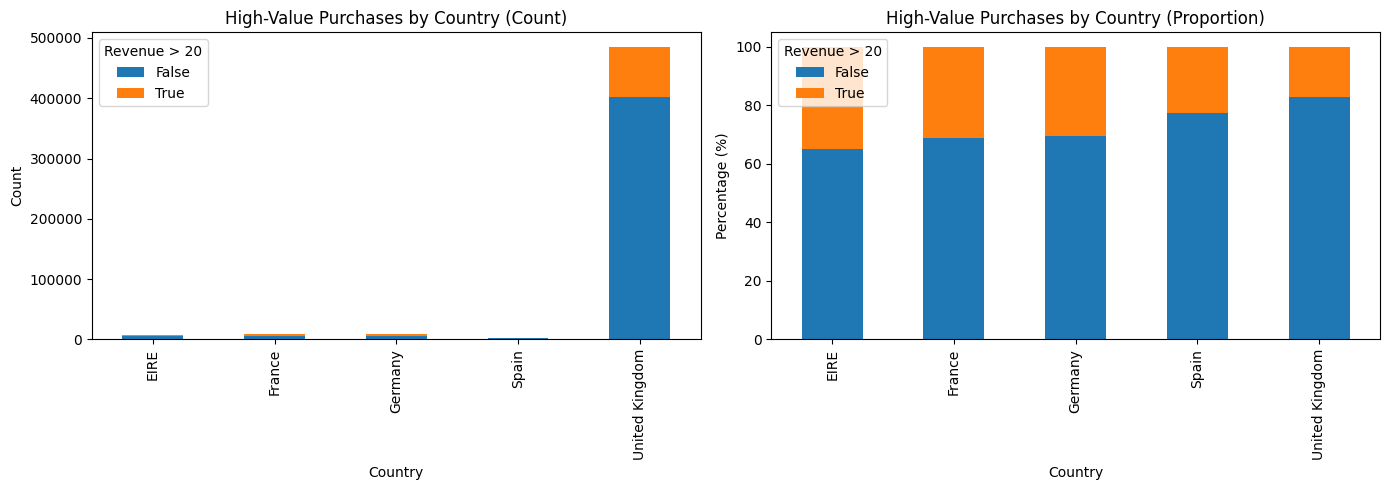

In [29]:
ct_pct = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
contingency_table.plot(kind='bar', ax=axes[0], stacked=True)
axes[0].set_title("High-Value Purchases by Country (Count)")
axes[0].set_ylabel("Count")
axes[0].legend(title="Revenue > 20")
ct_pct.plot(kind='bar', ax=axes[1], stacked=True)
axes[1].set_title("High-Value Purchases by Country (Proportion)")
axes[1].set_ylabel("Percentage (%)")
axes[1].legend(title="Revenue > 20")
plt.tight_layout()
plt.savefig("figures/chi_square_high_value.png", dpi=300, bbox_inches="tight")
plt.show()


###  Conclusion for Test 5
**Statistical Results:**
*   **Chi-Square Statistic:** 3661.1035
*   **P-value:** 0.0000
*   **Degrees of Freedom:** 4

**Interpretation:**
Since the **P-value is 0.0000**, which is much lower than our significance level ($\alpha = 0.05$), we **reject the null hypothesis ($H_0$)**.

This indicates a **statistically significant association** between the country and the likelihood of a high-value purchase. The proportions are not equal across the top 5 countries. Specifically, international customers (especially from **EIRE** and **France**) have a higher tendency to place high-value orders compared to customers in the **United Kingdom**.